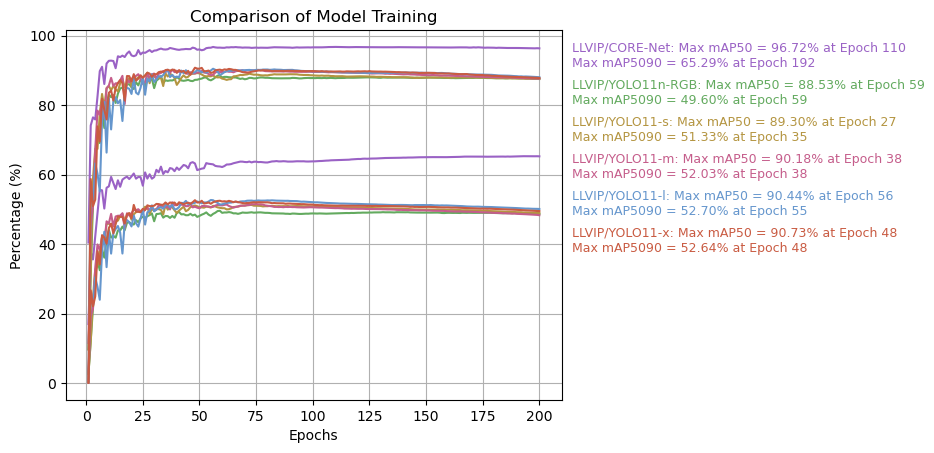

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_csv_comparison(filenames):
    colors = ["#9a62c5", "#63aa5f", "#b49541", "#c55d8b", "#6596cd", "#c95b42"]
    max_values = []
    for filename, color in zip(filenames, colors):
        if filename:
            try:
                df = pd.read_csv(f'runs/train/{filename}/results.csv')
                x = df.iloc[:, 0]
                y1 = df.iloc[:, 7] * 100  # mAP50
                y2 = df.iloc[:, 8] * 100  # mAP5090
                
                # 绘制 mAP50 和 mAP5090 曲线
                plt.plot(x, y1, label=f'{filename} mAP50', color=color)
                plt.plot(x, y2, label=f'{filename} mAP5090', linestyle='-', color=color)
                
                # 记录最大值和对应的 Epoch
                max_y1 = y1.max()
                max_x1 = x[y1.idxmax()]
                max_y2 = y2.max()
                max_x2 = x[y2.idxmax()]
                
                max_values.append((filename, max_x1, max_y1, max_x2, max_y2))
                
            except Exception as e:
                print(f"无法读取文件 {filename}/results.csv: {e}")
                continue  # 跳过当前文件，继续处理下一个文件
    
    # 标注最大值，避免重叠
    for i, (filename, max_x1, max_y1, max_x2, max_y2) in enumerate(max_values):
        y_offset = i * 0.1  # 调整间距
        plt.text(1.02, 0.9 - y_offset, f'{filename}: Max mAP50 = {max_y1:.2f}% at Epoch {max_x1}\nMax mAP5090 = {max_y2:.2f}% at Epoch {max_x2}', 
                 transform=plt.gca().transAxes, fontsize=9, color=colors[i])
    
    # 设置图表
    plt.xlabel('Epochs')
    plt.ylabel('Percentage (%)')
    plt.title('Comparison of Model Training')
    #plt.legend(loc='center left', bbox_to_anchor=(1, 0.2), fontsize=9, frameon=False)
    plt.grid(True)
    plt.show()

# 修改后的文件名列表
filenames = [
    #"DroneVehicle/CORE-Net",
    #"DroneVehicle/YOLO11n-RGB",
    #"DroneVehicle/YOLO11-s",
    #"DroneVehicle/YOLO11-m",
    #"DroneVehicle/YOLO11-l",
    #"DroneVehicle/YOLO11-x",
#####################################################################
    "LLVIP/CORE-Net",
    "LLVIP/YOLO11n-RGB",
    "LLVIP/YOLO11-s",
    "LLVIP/YOLO11-m",
    "LLVIP/YOLO11-l",
    "LLVIP/YOLO11-x",
]
plot_csv_comparison(filenames)
